In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('../additional_material/week7/Fish.csv')

In [117]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [118]:
df.tail()

,Species,Weight,Length1,Length2,Length3,Height,Width
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,13.8,15.0,16.2,2.9322,1.8792


In [119]:
df.sample(7)

,Species,Weight,Length1,Length2,Length3,Height,Width
68,Parkki,145.0,19.8,21.5,24.1,9.7364,3.1571
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
146,Smelt,7.5,10.0,10.5,11.6,1.9720,1.1600
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
20,Bream,575.0,31.3,34.0,39.5,15.1285,5.5695
66,Parkki,140.0,19.0,20.7,23.2,8.5376,3.2944
56,Whitefish,270.0,24.1,26.5,29.3,8.1454,4.2485


In [120]:
df.dtypes

Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [123]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [124]:
df.describe(include='all')

,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500


In [125]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

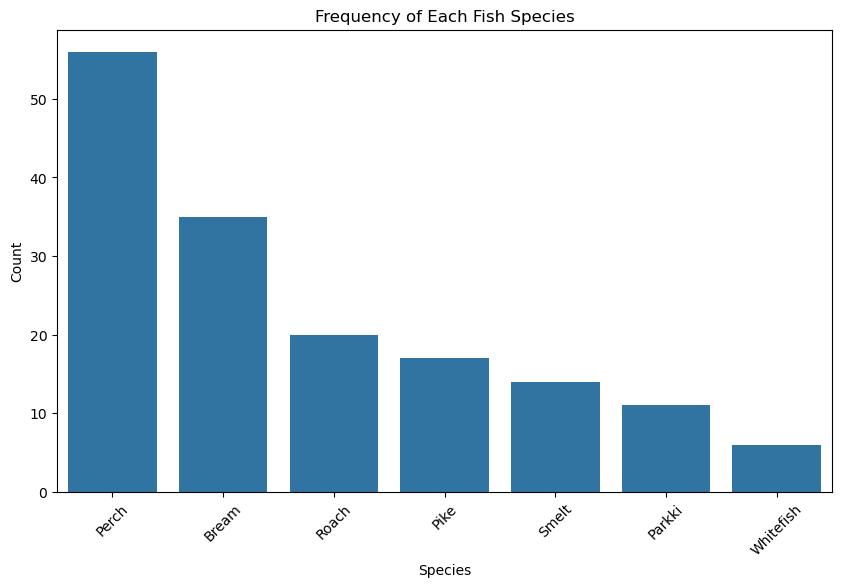

In [126]:
# plot thte frequency of each species vertically with relaeted colors and in ordered fashion
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Species', order=df['Species'].value_counts().index)
plt.title('Frequency of Each Fish Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

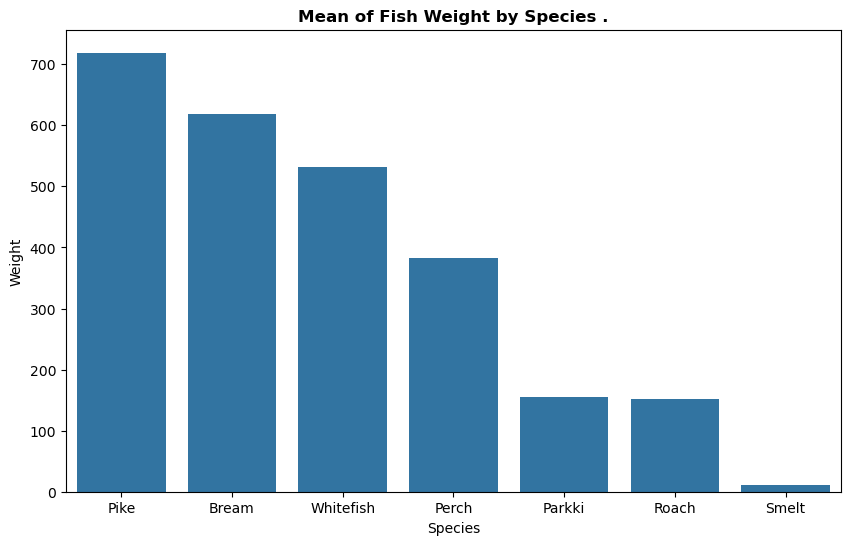

In [127]:
## Create barplot using seaborn between species and the mean of weight
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="Species",
    y="Weight",
    order=df.groupby('Species')['Weight'].mean().sort_values(ascending=False).index,
    errorbar=('ci', False),
    estimator='mean'
)

## title and labels name
plt.title('Mean of Fish Weight by Species .', weight="bold")
plt.xlabel('Species')
plt.ylabel('Weight')

## Show plot
plt.show()
plt.show()

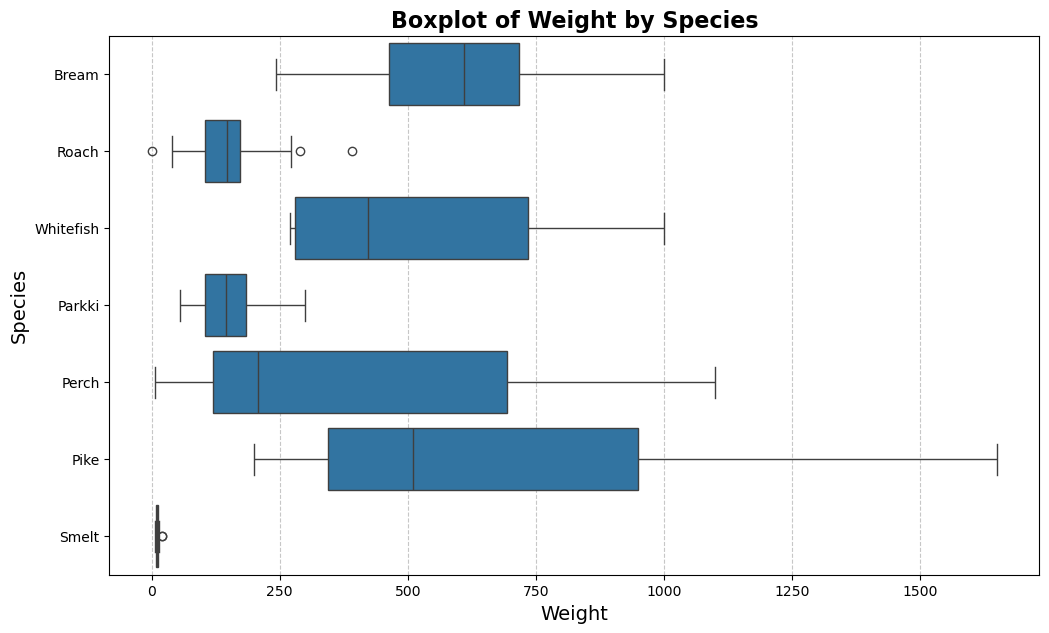

In [128]:
plt.figure(figsize=(12, 7))  # larger figure

sns.boxplot(data=df, x="Weight", y="Species")

plt.title('Boxplot of Weight by Species', fontsize=16, fontweight="bold")
plt.xlabel('Weight', fontsize=14)
plt.ylabel('Species', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


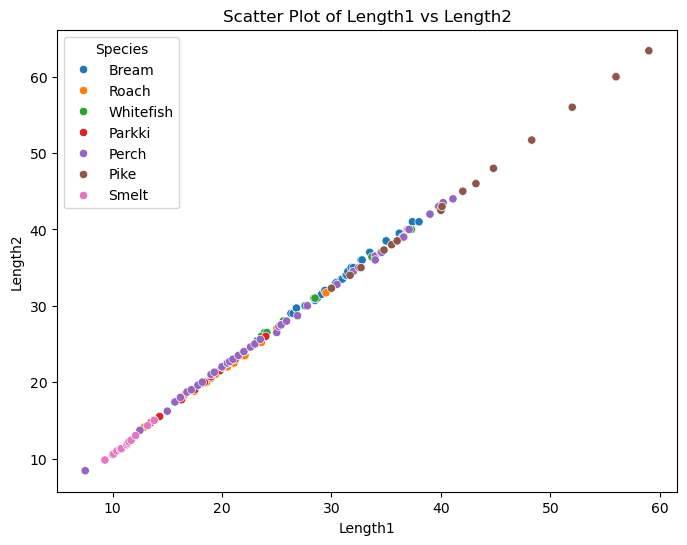

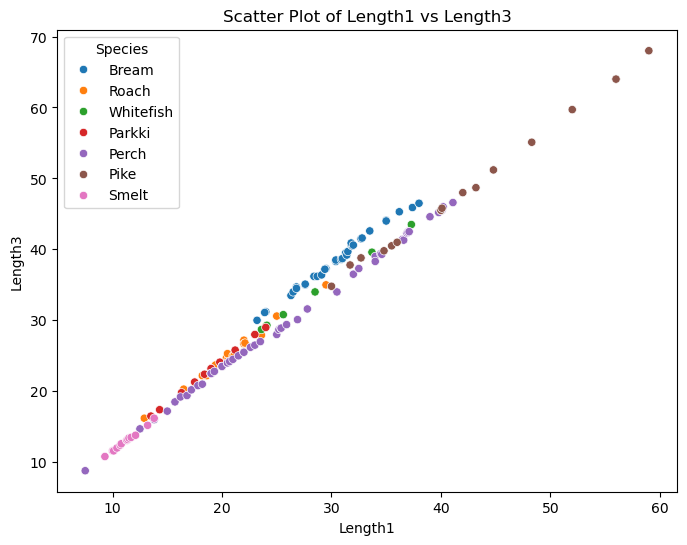

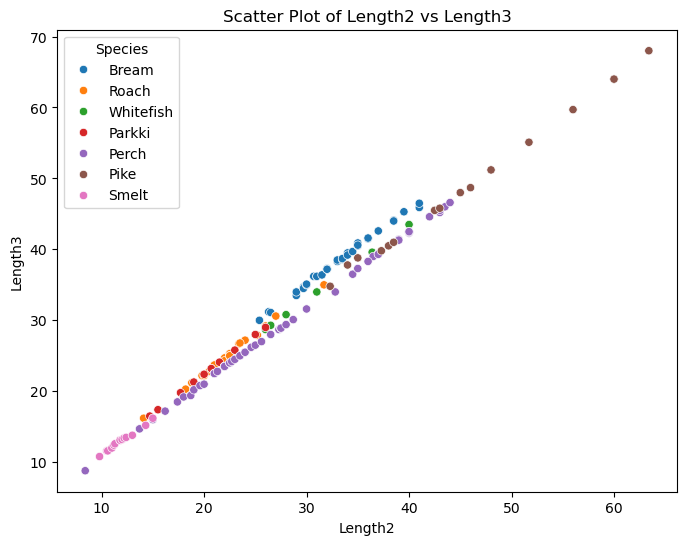

In [129]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Length1', y='Length2', hue='Species')
plt.title('Scatter Plot of Length1 vs Length2')
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Length1', y='Length3', hue='Species')
plt.title('Scatter Plot of Length1 vs Length3')
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Length2', y='Length3', hue='Species')
plt.title('Scatter Plot of Length2 vs Length3')
plt.show()

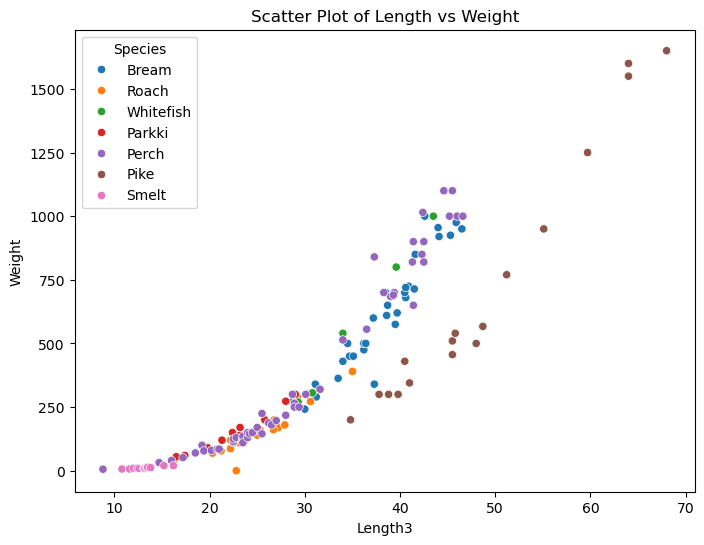

In [130]:
# plot scatter plot between weight and length3
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Length3', y='Weight', hue='Species')
plt.title('Scatter Plot of Length vs Weight')
plt.show()

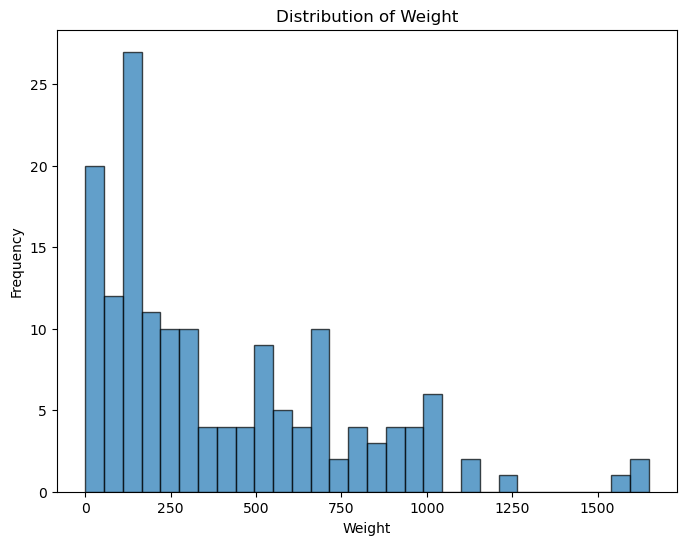

In [131]:
plt.figure(figsize=(8,6))
plt.hist(df['Weight'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

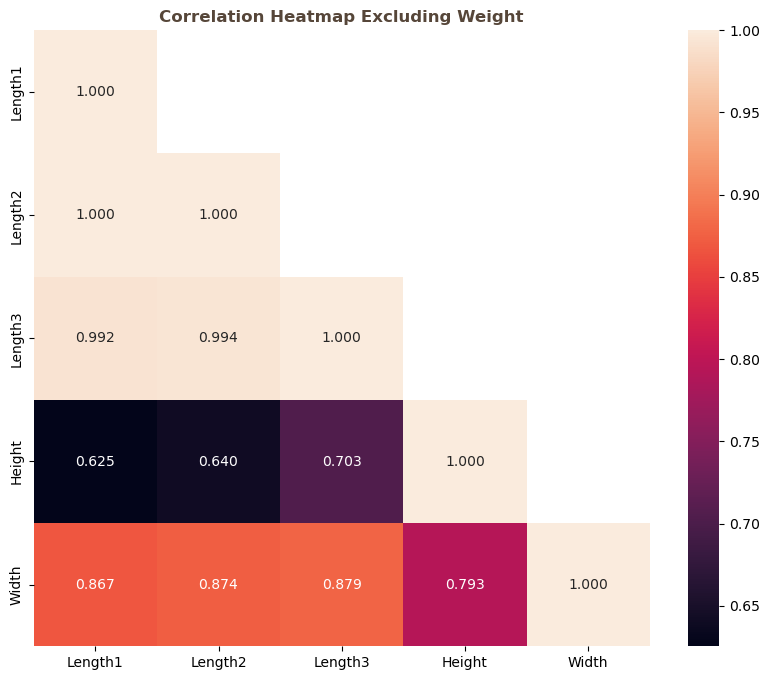

In [ ]:
multi_corr = df.drop("Weight", axis=1).corr(numeric_only=True)


mask = np.triu(np.ones_like(multi_corr), k=1)


plt.figure(figsize=(10, 8))


sns.heatmap(
    multi_corr,
    annot=True,
    mask=mask, 
    square=True,
    fmt="0.3f"
)

## title of the heatmap
plt.title("Correlation Heatmap Excluding Weight", weight="bold", color="#564639")

## Show the plot
plt.show()

In [133]:
df = df.drop(columns=['Length1', 'Length2'])
df.columns

Index(['Species', 'Weight', 'Length3', 'Height', 'Width'], dtype='object')

In [134]:
df['log_Weight'] = np.log(df['Weight'])
np.log(df['Weight'])

c:\Users\ahmed\datasci\env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ahmed\datasci\env\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


0      5.488938
1      5.669881
2      5.828946
3      5.894403
4      6.063785
         ...   
154    2.501436
155    2.595255
156    2.501436
157    2.980619
158    2.990720
Name: Weight, Length: 159, dtype: float64

In [135]:
df = df[df['Weight']>0]
df
df['log_Weight'] = np.log(df['Weight'])

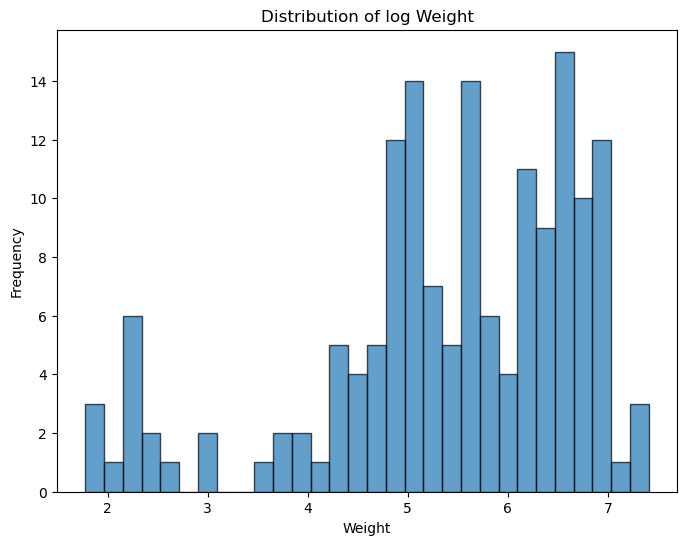

In [136]:
plt.figure(figsize=(8,6))
plt.hist(df['log_Weight'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of log Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()



The rule of thumb from your transcript is:

VIF < 5: Good 

VIF > 10: Bad (Redundant) 

Here is the code to calculate it for our remaining suspects (Length3, Height, Width).

In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = df[['Length3', 'Height', 'Width']]

vif_data = pd.DataFrame()
vif_data['Feature'] = variables.columns
vif_data['VIF'] = [variance_inflation_factor(variables.values, i ) for i in range(variables.shape[1])]
print(vif_data)

   Feature        VIF
0  Length3  33.403116
1   Height  14.534853
2    Width  45.888610


the goal is to have VIF scores below 10 (and ideally below 5).

Currently, we have:

Length3: ~33

Height: ~15

Width: ~46



Width had the highest score (~46), so it was the right one to remove.

In [138]:
df = df.drop(columns=['Width'])

In [139]:
variables = df[['Length3', 'Height']]

vif_data = pd.DataFrame()
vif_data['Feature'] = variables.columns
vif_data['VIF'] = [variance_inflation_factor(variables.values, i ) for i in range(variables.shape[1])]
print(vif_data)

   Feature        VIF
0  Length3  10.573546
1   Height  10.573546


In [140]:
import statsmodels.formula.api as smf

In [141]:
# Model A: Using Length3
model_a = smf.ols("log_Weight ~ Length3", data=df).fit()

# Model B: Using Height
model_b = smf.ols("log_Weight ~ Height", data=df).fit()

# Compare the AIC scores (Lower is better!)
print("AIC for Length3:", model_a.aic)
print("AIC for Height:", model_b.aic)

AIC for Length3: 263.782505438352
AIC for Height: 366.7471001284211


In [142]:
df = df.drop(columns=['Height'])
df

,Species,Weight,Length3,log_Weight
0,Bream,242.0,30.0,5.488938
1,Bream,290.0,31.2,5.669881
2,Bream,340.0,31.1,5.828946
3,Bream,363.0,33.5,5.894403
4,Bream,430.0,34.0,6.063785
...,...,...,...,...
154,Smelt,12.2,13.4,2.501436
155,Smelt,13.4,13.5,2.595255
156,Smelt,12.2,13.8,2.501436
157,Smelt,19.7,15.2,2.980619


### RQ1: Can we accurately predict the weight of a fish using just its Species and Length?

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
X = df[['Length3', 'Species']]
y = df['log_Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) 

In [145]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (StandardScaler(), ['Length3']),
    (OneHotEncoder(drop='first'), ['Species']),
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)

In [146]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
X_test_processed = preprocessor.transform(X_test)
y_pred = model.predict(X_test_processed)

In [148]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score,mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred) # squared=False gives RMSE
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.13498590361309976
RMSE: 0.17887633577601408
R2 Score: 0.9838087759017704


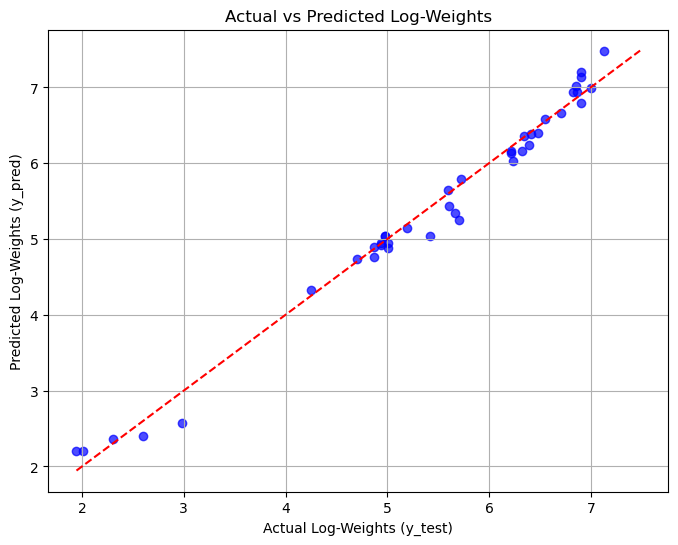

In [149]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Actual vs Predicted Log-Weights')
plt.xlabel('Actual Log-Weights (y_test)')
plt.ylabel('Predicted Log-Weights (y_pred)')
plt.grid(True)
plt.show()

In [150]:
residuals = y_test - y_pred

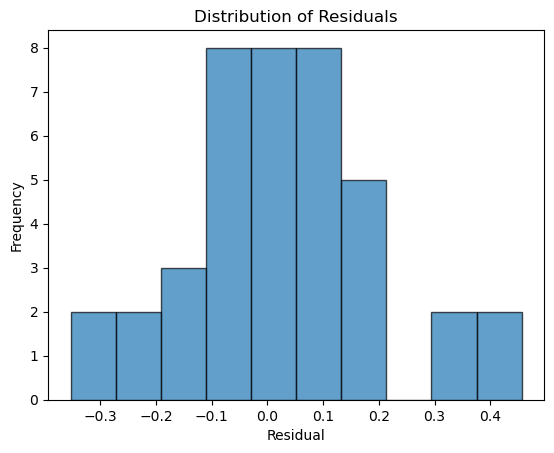

In [151]:
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

In [152]:
import statsmodels.formula.api as smf

# 1. Define the model
# Formula: "Target ~ Fixed_Predictor"
# Groups: The column that defines our clusters (Species)
mixed_model = smf.mixedlm("log_Weight ~ Length3", df, groups=df["Species"])

# 2. Fit the model
mixed_result = mixed_model.fit(reml=False)


# 3. Print the report
print(mixed_result.summary())
print("Mixed Model AIC:", mixed_result.aic)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_Weight
No. Observations: 158     Method:             ML        
No. Groups:       7       Scale:              0.0587    
Min. group size:  6       Log-Likelihood:     -16.6439  
Max. group size:  56      Converged:          Yes       
Mean group size:  22.6                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  2.185     0.240   9.105  0.000   1.715   2.656
Length3    0.100     0.003  37.092  0.000   0.095   0.106
Group Var  0.352     0.805                               

Mixed Model AIC: 41.287719514249375


### RQ2: Is it possible to reliably estimate a fish's weight using only its length, making the process simpler for the workers?

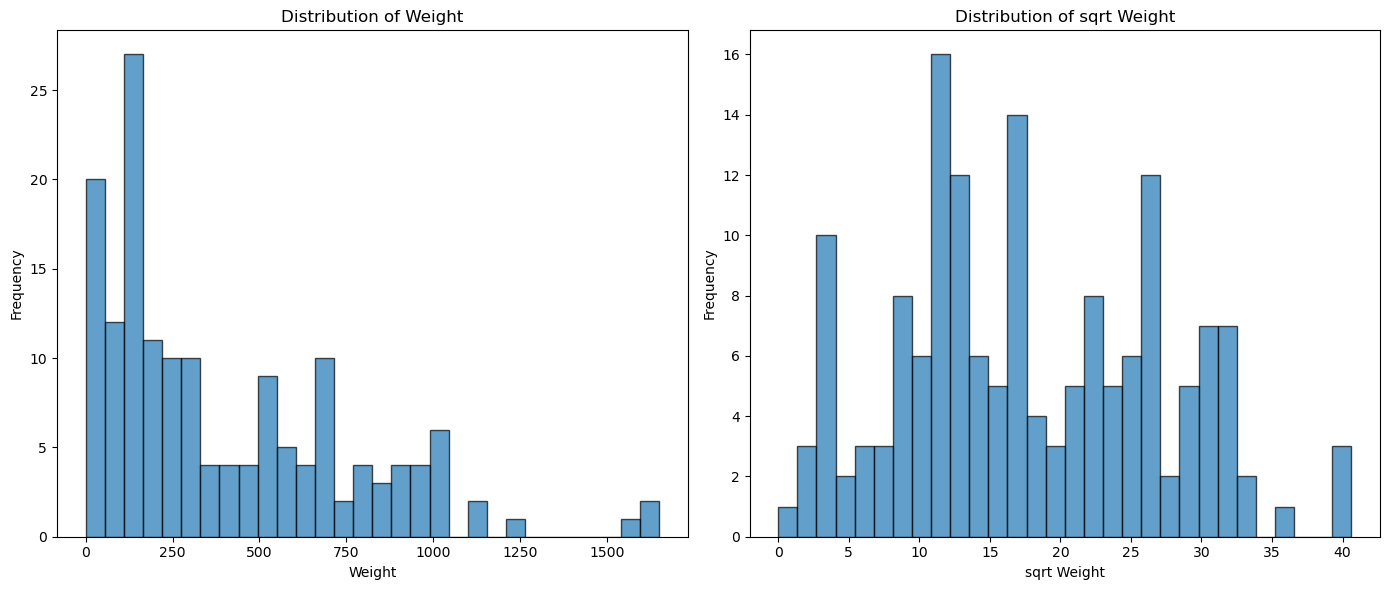

In [ ]:
df = pd.read_csv('../additional_material/week7/Fish.csv')
# drop length2 and length1
df = df.drop(columns=['Length1', 'Length2'])
df['sqrt_Weight'] = np.sqrt(df['Weight'])
plt.figure(figsize=(14,6))


plt.subplot(1, 2, 1)
plt.hist(df['Weight'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['sqrt_Weight'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of sqrt Weight')
plt.xlabel('sqrt Weight')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

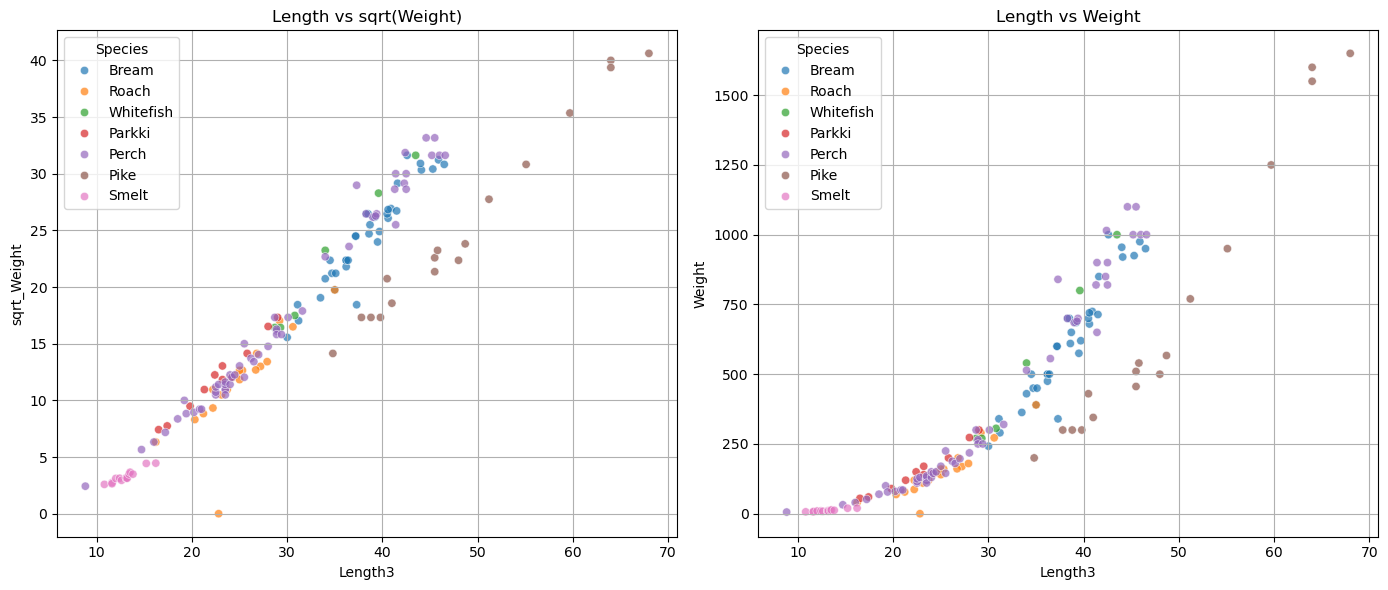

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))


sns.scatterplot(
    data=df,
    x='Length3',
    y='sqrt_Weight',
    hue='Species',
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title("Length vs sqrt(Weight)")
axes[0].grid(True)


sns.scatterplot(
    data=df,
    x='Length3',
    y='Weight',
    hue='Species',
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title("Length vs Weight")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [155]:

X = df[['Length3']]   # Only Length3 as predictor
y = df['sqrt_Weight']      # Target variable

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [157]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [158]:
y_pred_linear = linear_model.predict(X_test)


In [159]:
r2 = r2_score(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)

evals_df = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'MSE', 'RMSE'],
    'Value': [r2, mae, mse, rmse]
})
evals_df['Value'] = evals_df['Value'].round(4)
evals_df

,Metric,Value
0,R²,0.9258
1,MAE,2.0217
2,MSE,7.4377
3,RMSE,2.7272


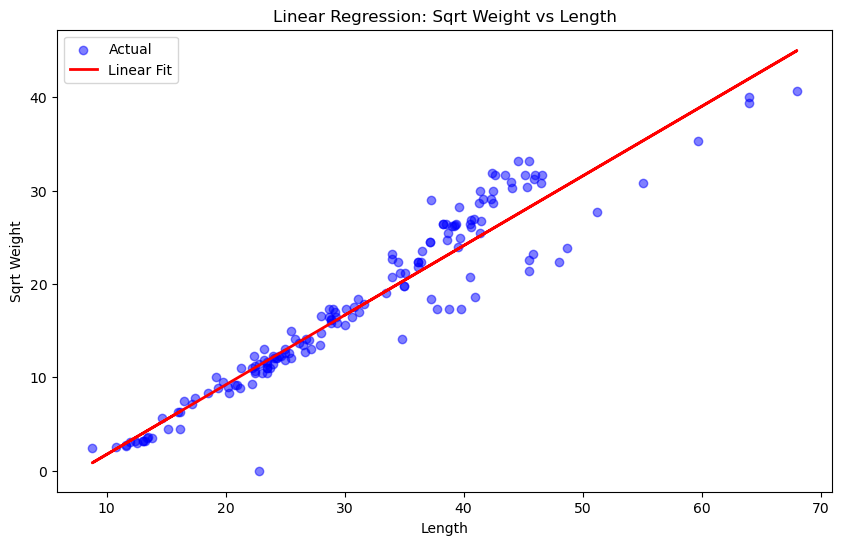

In [160]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual')
plt.plot(X, linear_model.predict(X), color='red', linewidth=2, label='Linear Fit')
plt.xlabel('Length')
plt.ylabel('Sqrt Weight')
plt.title('Linear Regression: Sqrt Weight vs Length')
plt.legend()
plt.show()

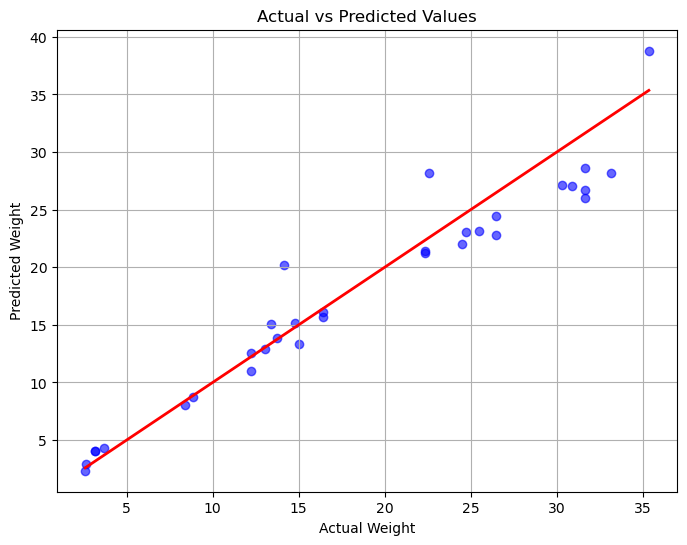

In [161]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()

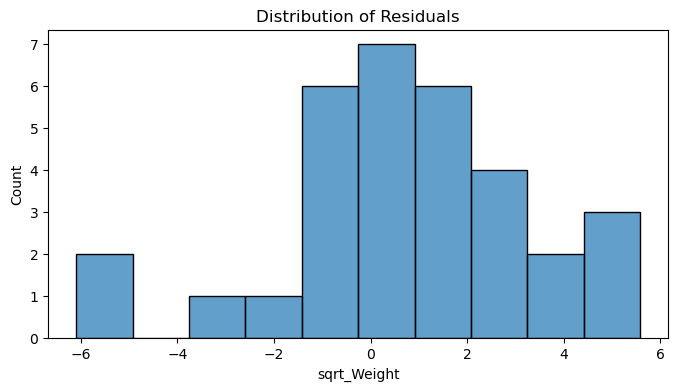

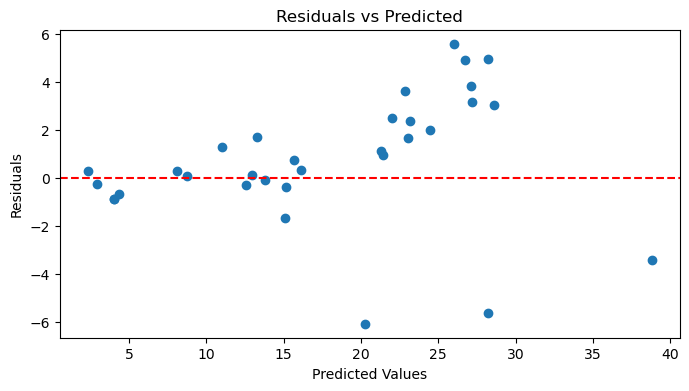

In [163]:
residuals = y_test - y_pred_linear

#Histogram
plt.figure(figsize=(8,4))
sns.histplot(residuals,bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Residuals')
plt.show()

# Scatter plot (Predicted vs Residuals)
plt.figure(figsize=(8,4))
plt.scatter(y_pred_linear, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [ ]:
X = sm.add_constant(X)

# fit OLS
linear_model = sm.OLS(y, X).fit()


print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:            sqrt_Weight   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     1594.
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           3.97e-84
Time:                        18:03:46   Log-Likelihood:                -386.54
No. Observations:                 159   AIC:                             777.1
Df Residuals:                     157   BIC:                             783.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.9397      0.632     -9.400      0.0

### RQ3: Is it possible to reliably estimate a fish's weight using its length, width and height?


In [ ]:
X = df[['Length3','Width','Height']]   # Only Length3 as predictor
y = df['sqrt_Weight']      # Target variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred_linear = linear_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)

evals_df = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'MSE', 'RMSE'],
    'Value': [r2, mae, mse, rmse]
})
evals_df['Value'] = evals_df['Value'].round(4)
evals_df

,Metric,Value
0,R²,0.9783
1,MAE,1.1723
2,MSE,2.1746
3,RMSE,1.4747


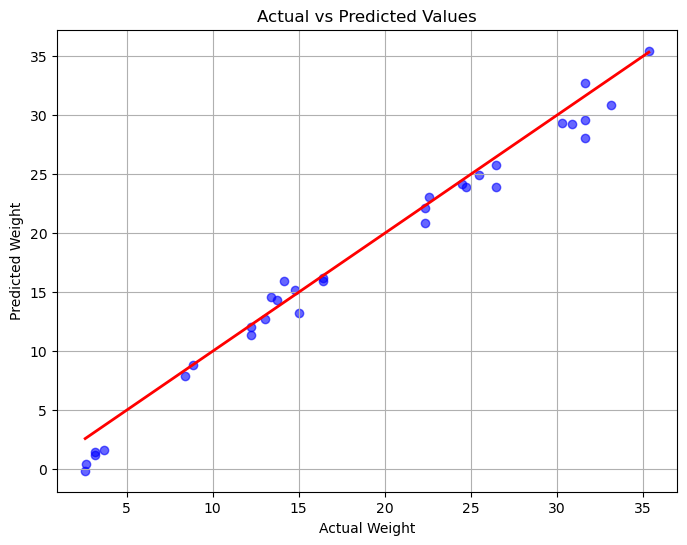

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()

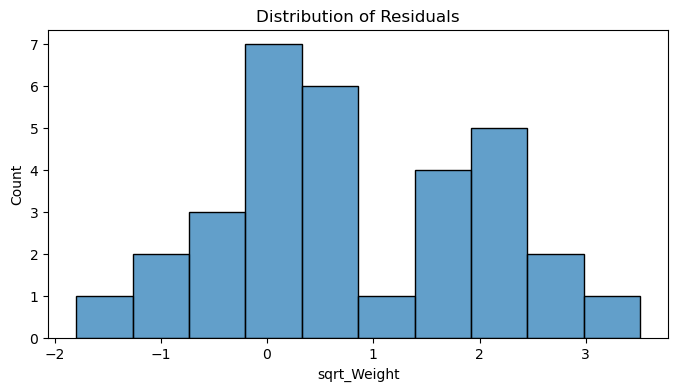

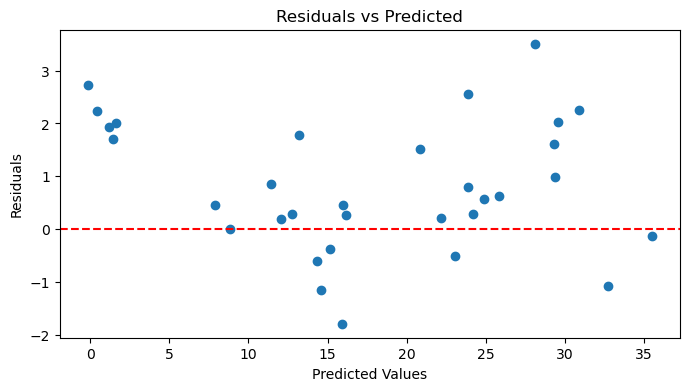

In [ ]:
residuals = y_test - y_pred_linear

#Histogram
plt.figure(figsize=(8,4))
sns.histplot(residuals,bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Residuals')
plt.show()

# Scatter plot (Predicted vs Residuals)
plt.figure(figsize=(8,4))
plt.scatter(y_pred_linear, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [ ]:
X = sm.add_constant(X)

# fit OLS
linear_model = sm.OLS(y, X).fit()


print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:            sqrt_Weight   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     1726.
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          8.03e-119
Time:                        18:03:47   Log-Likelihood:                -296.99
No. Observations:                 159   AIC:                             602.0
Df Residuals:                     155   BIC:                             614.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.0905      0.368    -19.245      0.0

The model remains highly accurate for weight prediction (our primary goal) but the individual coefficients (e.g., the exact contribution of Height alone) become unreliable. We cannot state which single dimension is mathematically "most important" when all three are present and this is because of the colinearity between the independent variables.